# Example: Bayesian Linear Regression & Posterior Sampling

Demonstrates exact conjugate Gaussian posterior inference, parameter weight sampling, and epistemic credible intervals.

Posterior MAP Weights: 1.8271, Bias: 0.4013
Sampled weight parameters:
 [[1.8341]
 [1.8032]
 [1.8444]
 [1.8488]
 [1.7823]]


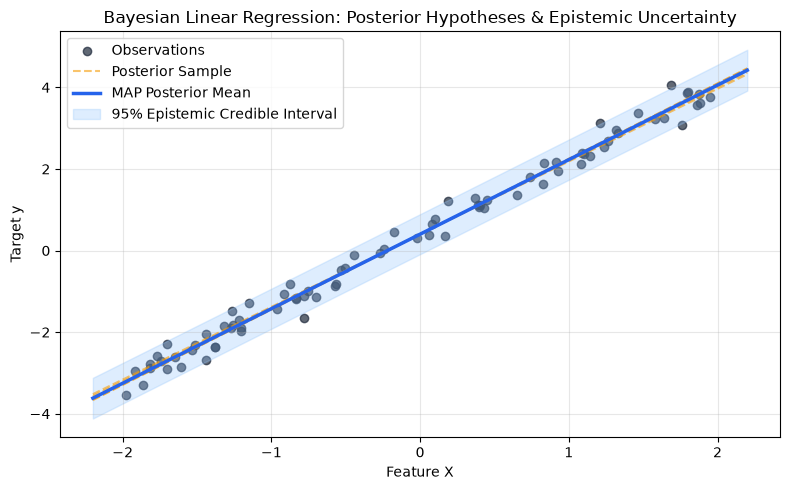

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.bayesian import BayesianLinearRegression

np.random.seed(42)
N = 80
X = np.random.uniform(-2, 2, size=(N, 1))
y = 1.8 * X[:, 0] + 0.4 + np.random.normal(0, 0.25, size=N)

bayes = BayesianLinearRegression(alpha=1.0, beta=16.0).fit(X, y)
w_samples = bayes.sample_weights(n_samples=5, random_state=42)

print(f"Posterior MAP Weights: {bayes.weights[0]:.4f}, Bias: {bayes.bias:.4f}")
print("Sampled weight parameters:\n", np.round(w_samples, 4))

# Visualize Posterior Mean & Sampled Hypotheses
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, color='#1e293b', alpha=0.7, label='Observations')
grid_X = np.linspace(-2.2, 2.2, 100).reshape(-1, 1)

# Sampled hypotheses from posterior
for i in range(len(w_samples)):
    plt.plot(grid_X[:, 0], grid_X @ w_samples[i] + bayes.bias, color='#f59e0b', alpha=0.6,
             linestyle='--', label='Posterior Sample' if i == 0 else "")

# MAP line
y_mean, y_std = bayes.predict(grid_X, return_std=True)
plt.plot(grid_X[:, 0], y_mean, color='#2563eb', lw=2.5, label='MAP Posterior Mean')
plt.fill_between(grid_X[:, 0], y_mean - 1.96 * y_std, y_mean + 1.96 * y_std,
                 color='#93c5fd', alpha=0.3, label='95% Epistemic Credible Interval')

plt.title("Bayesian Linear Regression: Posterior Hypotheses & Epistemic Uncertainty")
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- Calculating analytical posterior distributions over weights.
- Sampling plausible functions from parameter covariance $S_N$.
- Distinguishing epistemic variance from observation noise.